## Getting started
First we load in some timeseries data for a single VDS, so that we can have something to work with

In [2]:
# 3rd party imports
import logging
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import statsmodels.api as sm
from scipy.stats import norm, beta, weibull_min, cauchy, laplace, hypsecant, genhyperbolic
from statsmodels.tsa import stattools

# Logging setup
logger = logging.getLogger()
logger.handlers.clear()
stream_handler = logging.StreamHandler()
stream_handler.setLevel(logging.INFO)
logger.addHandler(stream_handler)

# Local imports
from transportation_models.utils.data_processing import PeMSDataProcessor, TargetNormalization

# Data loading
DataProcessor = PeMSDataProcessor(
    root_directory="/Volumes/easystore/work/boulder/Caltrans/PeMS",
    metadata_filepath="/Volumes/easystore/work/boulder/Caltrans/PeMS/metadata/station_metadata_calibrated.csv",
    save_transforms=False
)
station_id = "407219"
df = DataProcessor.load_data_by_id(station_id=station_id)
df = DataProcessor.standardize_timeseries(df=df)
df.head()

,timestamp,Station ID,pct_observed,Lanes,Type,Abs PM,Length,capacity,free_flow_speed,congestion_wave_speed,critical_density,flow_[veh/hr-lane],density_[veh/mi-lane]
0,2022-01-01 00:00:00,407219.0,0.0,6,Mainline,12.13,0.43,1270.134506,63.076149,-6.512609,20.136526,324.0,4.655172
1,2022-01-01 00:05:00,407219.0,0.0,6,Mainline,12.13,0.43,1270.134506,63.076149,-6.512609,20.136526,318.0,4.588745
2,2022-01-01 00:10:00,407219.0,0.0,6,Mainline,12.13,0.43,1270.134506,63.076149,-6.512609,20.136526,310.0,4.473304
3,2022-01-01 00:15:00,407219.0,0.0,6,Mainline,12.13,0.43,1270.134506,63.076149,-6.512609,20.136526,300.0,4.335260
4,2022-01-01 00:20:00,407219.0,0.0,6,Mainline,12.13,0.43,1270.134506,63.076149,-6.512609,20.136526,286.0,4.138929


array([<Axes: xlabel='timestamp'>, <Axes: xlabel='timestamp'>,
       <Axes: xlabel='timestamp'>], dtype=object)

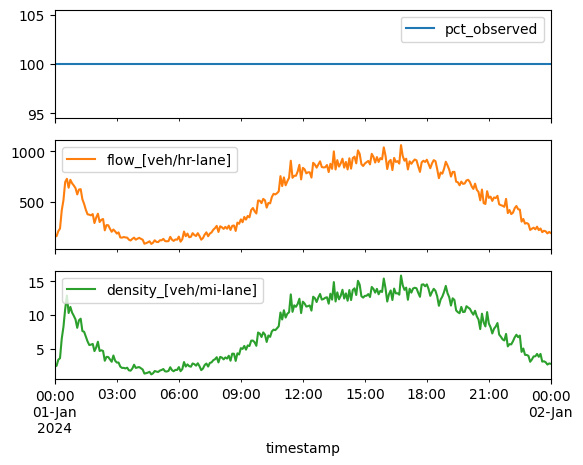

In [3]:
# Visualize the timeseries
ts_start = pd.Timestamp(year=2024, month=1, day=1)
ts_end = pd.Timestamp(year=2024, month=1, day=2)
df.loc[((df['timestamp'] >= ts_start) & (df['timestamp'] <= ts_end)), ['timestamp', 'pct_observed', 'flow_[veh/hr-lane]', 'density_[veh/mi-lane]']].set_index('timestamp').plot(subplots=True)

## Trend Stationarity
Based on the shape of the timeseries data that we see above, we might suspect that there is some kind of trend stationarity to the data (i.e., counts on Monday afternoon at 5pm this week are probably similar to counts at 5pm on Monday next week).
Going off of this, let's now build some tools to analyze the trend. We'll want:
1) A function to calculate some aggregate statistics (e.g., mean, variance, etc.) of the timeseries after it has been grouped into bins which we expect to be stationary (e.g., Mondays at 5pm)
2) A function to eliminate the seasonal variation in our timeseries (in the hopes that the result *is* weakly stationary)
3) A function to analyze how stationary the result is

In [4]:
# Function #1
aggregation_df = DataProcessor.get_daily_aggregation(df, colname='flow_[veh/hr-lane]', aggregation_type='mean')
aggregation_df.head()

weekday,5min_block,Mon,Tue,Wed,Thu,Fri,Sat,Sun
timestamp,,,,,,,,
1970-01-01 00:00:00,0.000000,286.560510,275.070064,286.012821,296.717949,305.294872,419.656051,450.764331
1970-01-01 00:05:00,0.083333,274.025478,258.968153,270.910256,281.051282,299.051282,403.923567,438.267516
1970-01-01 00:10:00,0.166667,264.840764,255.974522,271.000000,277.717949,285.782051,394.802548,421.668790
1970-01-01 00:15:00,0.250000,259.656051,256.687898,266.910256,277.294872,284.589744,386.585987,414.904459
1970-01-01 00:20:00,0.333333,247.159236,239.528662,244.076923,256.974359,268.935897,373.273885,391.859873


In [5]:
# Function #2 (fair warning: cell takes ~2mins to run)
whitened_df = DataProcessor.whiten_timeseries(df)
whitened_df.head()

,timestamp,Station ID,pct_observed,Lanes,Type,Abs PM,Length,capacity,free_flow_speed,congestion_wave_speed,...,flow_[veh/hr-lane],density_[veh/mi-lane],weekday,5min_block,mean_flow,stddev_flow,mean_density,stddev_density,whitened_flow,whitened_density
0,2022-01-01 00:00:00,407219.0,0.0,6,Mainline,12.13,0.43,1270.134506,63.076149,-6.512609,...,324.0,4.655172,5,0.000000,419.656051,107.212269,6.294340,2.151970,-0.892212,-0.761705
1,2022-01-01 00:05:00,407219.0,0.0,6,Mainline,12.13,0.43,1270.134506,63.076149,-6.512609,...,318.0,4.588745,5,0.083333,403.923567,103.810450,6.093392,2.008535,-0.827697,-0.749127
2,2022-01-01 00:10:00,407219.0,0.0,6,Mainline,12.13,0.43,1270.134506,63.076149,-6.512609,...,310.0,4.473304,5,0.166667,394.802548,100.883243,5.956335,1.869557,-0.840601,-0.793252
3,2022-01-01 00:15:00,407219.0,0.0,6,Mainline,12.13,0.43,1270.134506,63.076149,-6.512609,...,300.0,4.335260,5,0.250000,386.585987,97.187437,5.844024,1.753181,-0.890917,-0.860587
4,2022-01-01 00:20:00,407219.0,0.0,6,Mainline,12.13,0.43,1270.134506,63.076149,-6.512609,...,286.0,4.138929,5,0.333333,373.273885,95.038765,5.676374,1.752688,-0.918298,-0.877193


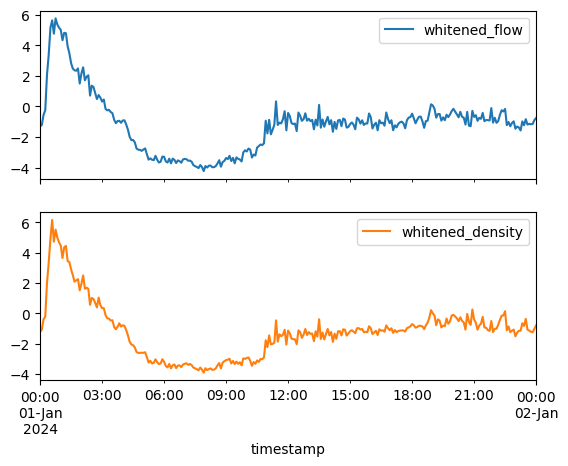

In [6]:
# Visualize the results!
ts_start = pd.Timestamp(year=2024, month=1, day=1)
ts_end = pd.Timestamp(year=2024, month=1, day=2)
ax = whitened_df.loc[((whitened_df['timestamp'] >= ts_start) & (whitened_df['timestamp'] <= ts_end)), ['timestamp', 'whitened_flow', 'whitened_density']].set_index('timestamp').plot(subplots=True)


## Stationary Analysis

/Users/robstallman/.pyenv/versions/transportation-models-env/lib/python3.10/site-packages/scipy/stats/_continuous_distns.py:795: RuntimeWarning: invalid value encountered in sqrt
  sk = 2*(b-a)*np.sqrt(a + b + 1) / (a + b + 2) / np.sqrt(a*b)
/Users/robstallman/.pyenv/versions/transportation-models-env/lib/python3.10/site-packages/scipy/stats/_continuous_distns.py:800: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  a, b = optimize.fsolve(func, (1.0, 1.0))


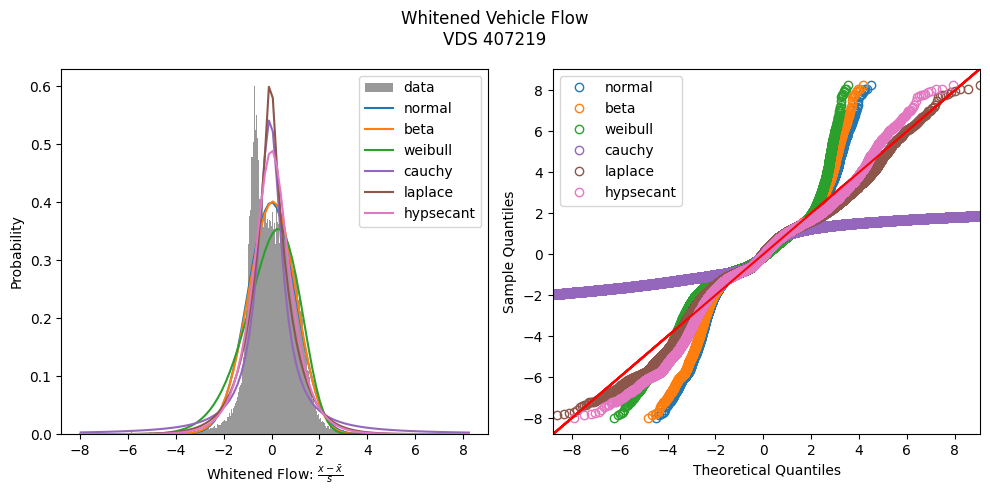

In [7]:
metric = 'flow'

# Generate a histogram of the whitened timeseries
data = whitened_df[f'whitened_{metric}'].dropna()
x = np.linspace(data.min(), data.max(), 100)
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(10,5))

# Use 'density=True' so the histogram area sums to 1, matching the PDF
ax1.hist(data, bins=1000, density=True, alpha=0.4, color='k', label='data')

# Fit a normal distribution to the data
mu, sigma = norm.fit(data)
normal_dist = norm(mu, sigma)
normal_pdf = norm.pdf(x, mu, sigma)

# Fit a beta distribution to the data
a, b, loc1, scale1 = beta.fit(data)
beta_dist = beta(a,b,loc1,scale1)
beta_pdf = beta.pdf(x, a, b, loc1, scale1)

# Fit a weibull distribution to the data
c, loc2, scale2 = weibull_min.fit(data)
weibull_dist = weibull_min(c, loc2, scale2)
weibull_pdf = weibull_min.pdf(x, c, loc2, scale2)

# Fit a cauchy distribution to the data
loc3, scale3 = cauchy.fit(data)
cauchy_dist = cauchy(loc3, scale3)
cauchy_pdf = cauchy.pdf(x, loc3, scale3)

# Fit a laplace distribution to the data
loc4, scale4 = laplace.fit(data)
laplace_dist = laplace(loc4, scale4)
laplace_pdf = laplace.pdf(x, loc4, scale4)

# Fit a hypsecant distribution to the data
loc5, scale5 = hypsecant.fit(data)
hypsecant_dist = hypsecant(loc5, scale5)
hypsecant_pdf = hypsecant.pdf(x, loc5, scale5)

# Fit a hyperbolic distribution to the data
# p, a, b, loc, scale = genhyperbolic.fit(data)
# hyperbolic_dist = genhyperbolic(p,a,b,loc,scale)
# hyperbolic_pdf = genhyperbolic.pdf(x, p, a, b, loc, scale)

# Plot the fitted distribution curves
ax1.plot(x, normal_pdf, 'tab:blue', label='normal')
ax1.plot(x, beta_pdf, 'tab:orange', label='beta')
ax1.plot(x, weibull_pdf, 'tab:green', label='weibull')
ax1.plot(x, cauchy_pdf, 'tab:purple', label='cauchy')
ax1.plot(x, laplace_pdf, 'tab:brown', label='laplace')
ax1.plot(x, hypsecant_pdf, 'tab:pink', label='hypsecant')
#ax1.plot(x, hyperbolic_pdf, 'cyan', label='hyperbolic')

# Add the QQ plots
sm.qqplot(data, dist=normal_dist, ax=ax2, line='45', label='normal', markerfacecolor='none', markeredgecolor='tab:blue')
sm.qqplot(data, dist=beta_dist, ax=ax2, line='45', label='beta', markerfacecolor='none', markeredgecolor='tab:orange')
sm.qqplot(data, dist=weibull_dist, ax=ax2, line='45', label='weibull', markerfacecolor='none', markeredgecolor='tab:green')
sm.qqplot(data, dist=cauchy_dist, ax=ax2, line='45', label='cauchy', markerfacecolor='none', markeredgecolor='tab:purple')
sm.qqplot(data, dist=laplace_dist, ax=ax2, line='45', label='laplace', markerfacecolor='none', markeredgecolor='tab:brown')
sm.qqplot(data, dist=hypsecant_dist, ax=ax2, line='45', label='hypsecant', markerfacecolor='none', markeredgecolor='tab:pink')

# Add plot elements
ax1.set_xlabel(f"Whitened {metric.title()}: " + "$\\frac{x-\\bar{x}}{s}$")
ax1.set_ylabel("Probability")
ax1.legend()
ax2.set_xlabel("Theoretical Quantiles")
ax2.set_ylabel("Sample Quantiles")
ax2.legend()
plt.suptitle(f"Whitened Vehicle {metric.title()}\nVDS {station_id}")

# Fix spacing
plt.tight_layout()

# Show
plt.show()

In [ ]:
summary = {
    'station_id':[],
    'metric':[],
    'skew':[],
    'kurtosis':[]
}

station_ids = DataProcessor.metadata_df['Station ID'].unique()

for idx, station_id in enumerate(station_ids):
    print(f"Working on station {idx+1}/{len(station_ids)}")
    # Load and process data
    df = DataProcessor.load_data_by_id(station_id=station_id)
    df = DataProcessor.standardize_timeseries(df=df)
    whitened_df = DataProcessor.whiten_timeseries(df)

    # Calculate kurtosis and skew
    for metric in ['whitened_flow', 'whitened_density']:
        skew = whitened_df[metric].skew()
        kurt = whitened_df[metric].kurt()

        # Add to summary
        summary['station_id'].append(station_id)
        summary['metric'].append(metric)
        summary['skew'].append(skew)
        summary['kurtosis'].append(kurt)

# Turn it into a DataFrame!
stats_df = pd.DataFrame(summary)

# Create a plot
stats_df.loc[stats_df['metric'] == 'whitened_density'].set_index('station_id').plot(kind='barh', figsize=(7,10), subplots=True, sharey=True, layout=(1,2), ylabel="Station ID", grid=True, legend=False, title='Whitened Density Timeseries Moments')
stats_df.loc[stats_df['metric'] == 'whitened_flow'].set_index('station_id').plot(kind='barh', figsize=(7,10), subplots=True, sharey=True, layout=(1,2), ylabel="Station ID", grid=True, legend=False, title='Whitened Flow Timeseries Moments')

In [20]:
# Calculate autocorrelation
ndays = 1
periods = ndays * 24 * 12
nlags = periods-1
acf = stattools.acf(whitened_df['whitened_flow'], nlags=nlags, missing='conservative', fft=True, adjusted=True)
raw_acf = stattools.acf(df['flow_[veh/hr-lane]'], nlags=nlags, missing='conservative', fft=True, adjusted=True)
times = pd.date_range(start='2026-01-01 00:00:00', periods=periods, freq='5min')
stats_df = pd.DataFrame(data={'whitened_acf':acf, 'raw_acf': raw_acf}, index=times)
stats_df

,whitened_acf,raw_acf
2026-01-01 00:00:00,1.000000,1.000000
2026-01-01 00:05:00,0.858270,0.979494
2026-01-01 00:10:00,0.839226,0.974412
2026-01-01 00:15:00,0.826276,0.969643
2026-01-01 00:20:00,0.814374,0.965109
...,...,...
2026-01-01 23:35:00,0.485364,0.861664
2026-01-01 23:40:00,0.487815,0.864779
2026-01-01 23:45:00,0.491436,0.867922
2026-01-01 23:50:00,0.494966,0.871039


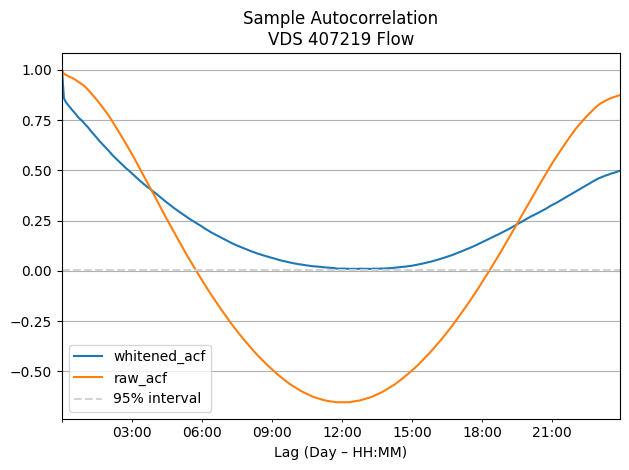

In [21]:
# Visualize!
ax = stats_df.plot()
interval = 2/np.sqrt(len(whitened_df))
ax.axhline(interval, color='lightgrey', linestyle='--', label='95% interval')

# Force ticks every 12 hours
ax.xaxis.set_major_locator(mdates.HourLocator(byhour=[0,12]))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d - %H:%M'))
ax.tick_params(axis='x', labelrotation=45)

plt.xlabel("Lag (Day – HH:MM)")
plt.title(f"Sample Autocorrelation\nVDS {station_id} Flow")
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()
